# Classification de CVs — Prédiction de `passed_next_stage`

Objectif : prédire si un CV passe à l'étape suivante du processus de recrutement.  
**Priorité métier : maximiser la précision** (éviter les faux positifs = ne pas valider des CVs insuffisants).  
Le recall est secondaire : on accepte de rater quelques bons profils pour ne pas faire passer de mauvais.

**Pipeline :**
1. Chargement & exploration
2. Feature engineering
3. Preprocessing (scaler + OHE + TF-IDF)
4. Modélisation avec SMOTE (déséquilibre de classes)
5. Sélection de features + optimisation du seuil (F0.5)
6. Modèles ensemblistes (RF, GB)
7. Calibration + interprétabilité SHAP
8. Conclusion & modèle retenu

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Chargement & exploration

In [2]:
df = pd.read_csv('../data/cv_dataset.csv')

print(f'Shape : {df.shape}')
print('\nTypes & valeurs manquantes :')
print(pd.concat([df.dtypes.rename('dtype'), df.isnull().sum().rename('nulls')], axis=1))
df.head()

Shape : (200, 21)

Types & valeurs manquantes :
                           dtype  nulls
cv_id                        str      0
age                        int64      0
distance_ville_haute_km  float64      0
target_role                  str      0
total_experience_years   float64      0
total_gap_months           int64      0
nb_gaps                    int64      0
education_degree             str      0
education_field              str      0
education_school             str      0
education_score            int64      0
skills                       str      0
certifications               str      0
number_of_experiences      int64      0
lang_fr                    int64      0
lang_en                    int64      0
lang_de                    int64      0
lang_es                    int64      0
lang_it                    int64      0
lang_other_score_sum       int64      0
passed_next_stage          int64      0


,cv_id,age,distance_ville_haute_km,target_role,total_experience_years,total_gap_months,nb_gaps,education_degree,education_field,education_school,...,skills,certifications,number_of_experiences,lang_fr,lang_en,lang_de,lang_es,lang_it,lang_other_score_sum,passed_next_stage
0,cv_0001.txt,30,7585.14,Software Engineer,2.4,14,1,Bachelor of Science,Computer Science,Indian Institute of Technology Delhi,...,"C#, Confluence, SQL, Git, Python, ETL basics, ...",Professional Scrum Developer,2,0,6,0,0,0,0,0
1,cv_0002.txt,39,1087.96,Frontend Developer,6.5,25,2,Master of Science,Information Technology,Indian Institute of Technology Delhi,...,"Testing Library, Next.js, React, JavaScript, H...","Professional Scrum Master I, AWS Cloud Practit...",3,6,5,0,0,0,0,0
2,cv_0003.txt,34,8038.04,Backend Developer,7.3,24,2,Master of Science,Information Technology,Trinity College Dublin,...,"REST APIs, Java, Docker, Redis, PostgreSQL, AP...","Scrum Fundamentals Certified, ITIL Foundation,...",3,0,6,0,0,0,0,1
3,cv_0004.txt,34,319.28,Software Engineer,7.3,0,0,Bachelor of Science,Software Engineering,Politecnico di Milano,...,"Docker, SQL, Java, System integration, Object-...",Professional Scrum Developer,1,0,5,6,0,0,0,0
4,cv_0005.txt,39,158.95,Software Engineer,9.5,32,2,Bachelor of Science,Computer Science,University of Colorado Boulder,...,"REST APIs, Python, SQL, Unit testing, Document...","AWS Certified Developer, Azure Developer Assoc...",3,0,6,3,0,0,0,1


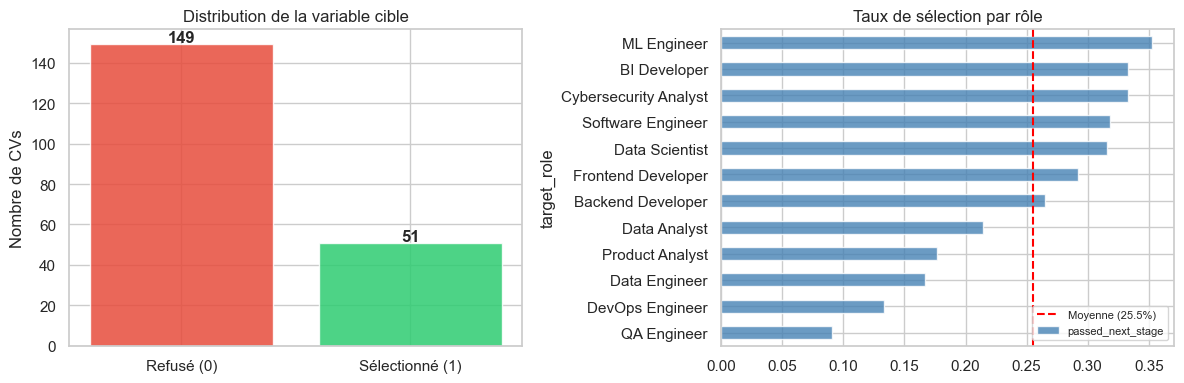

Taux de sélection global : 25.5%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution de la variable cible
counts = df['passed_next_stage'].value_counts()
axes[0].bar(['Refusé (0)', 'Sélectionné (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='white')
axes[0].set_title('Distribution de la variable cible')
axes[0].set_ylabel('Nombre de CVs')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Taux de sélection par rôle (utile pour déceler des biais)
role_rate = df.groupby('target_role')['passed_next_stage'].mean().sort_values()
role_rate.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Taux de sélection par rôle')
axes[1].axvline(df['passed_next_stage'].mean(), color='red', linestyle='--',
                label=f"Moyenne ({df['passed_next_stage'].mean():.1%})")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"Taux de sélection global : {df['passed_next_stage'].mean():.1%}")

## 3. Feature Engineering

On crée des features dérivées pour mieux représenter la structure temporelle du CV,
en évitant la redondance entre `nb_gaps` et `total_gap_months`.

In [4]:
# Durée moyenne d'un gap : résout la colinéarité nb_gaps / total_gap_months
df['avg_gap_duration'] = df['total_gap_months'] / (df['nb_gaps'] + 1)

# Part de la carrière passée en gap (signal de stabilité)
df['gap_ratio'] = df['total_gap_months'] / (
    df['total_experience_years'] * 12 + df['total_gap_months'] + 1
)

# Nombre de skills distincts listés
df['skills_count'] = df['skills'].fillna('').apply(
    lambda x: len([s.strip() for s in x.split(',') if s.strip()])
)

# Présence de certifications (binaire)
df['has_certif'] = df['certifications'].fillna('').str.strip().ne('').astype(int)

print(df[['avg_gap_duration', 'gap_ratio', 'skills_count', 'has_certif']].describe())

       avg_gap_duration   gap_ratio  skills_count  has_certif
count        200.000000  200.000000    200.000000       200.0
mean           4.726667    0.142159     12.605000         1.0
std            4.685266    0.155486      1.790251         0.0
min            0.000000    0.000000      8.000000         1.0
25%            0.000000    0.000000     11.000000         1.0
50%            5.166667    0.137668     13.000000         1.0
75%            9.000000    0.261118     14.000000         1.0
max           14.000000    0.851064     17.000000         1.0


In [5]:
TARGET    = 'passed_next_stage'
DROP_COLS = ['cv_id']

# Features numériques — avg_gap_duration et gap_ratio remplacent nb_gaps et total_gap_months
NUMERIC_FEATURES = [
    'age', 'distance_ville_haute_km', 'total_experience_years',
    'nb_gaps', 'gap_ratio', 'education_score', 'number_of_experiences',
    'skills_count', 'has_certif',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
]

# education_school exclu : cardinalité trop haute pour le volume disponible
CATEGORICAL_FEATURES = ['target_role', 'education_degree', 'education_field']

TEXT_SKILLS         = 'skills'
TEXT_CERTIFICATIONS = 'certifications'

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

print(f"Numériques : {len(NUMERIC_FEATURES)}  |  Catégorielles : {len(CATEGORICAL_FEATURES)}  |  Texte : 2")
print(f"X : {X.shape}  |  y : {y.shape}  |  taux positifs : {y.mean():.1%}")

Numériques : 15  |  Catégorielles : 3  |  Texte : 2
X : (200, 23)  |  y : (200,)  |  taux positifs : 25.5%


## 4. Split train / test stratifié

In [6]:
# Stratification pour préserver le ratio de classe dans chaque split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} obs  |  positifs : {y_train.mean():.1%}")
print(f"Test  : {X_test.shape[0]} obs   |  positifs : {y_test.mean():.1%}")

Train : 160 obs  |  positifs : 25.6%
Test  : 40 obs   |  positifs : 25.0%


## 5. Preprocessing Pipeline

In [7]:
# Nettoyage du texte avant vectorisation
X_train, X_test = X_train.copy(), X_test.copy()
for col in [TEXT_SKILLS, TEXT_CERTIFICATIONS]:
    X_train[col] = X_train[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)
    X_test[col]  = X_test[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)

# Sous-pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# TF-IDF avec token_pattern adapté aux termes techniques (ex: C++, .NET)
skills_tfidf = TfidfVectorizer(max_features=20, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2)
certif_tfidf = TfidfVectorizer(max_features=15, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2)

preprocessor = ColumnTransformer([
    ('num',    numeric_pipeline,     NUMERIC_FEATURES),
    ('cat',    categorical_pipeline, CATEGORICAL_FEATURES),
    ('skills', skills_tfidf,         TEXT_SKILLS),
    ('certif', certif_tfidf,         TEXT_CERTIFICATIONS),
], remainder='drop')

print("Preprocessor défini ✓")

Preprocessor défini ✓


## 6. Régression Logistique — baseline

Point de départ : LR L2 avec SMOTE pour corriger le déséquilibre de classes.

In [8]:
lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   LogisticRegression(
                         C=1.0, class_weight='balanced',
                         max_iter=1000, random_state=42, solver='lbfgs'
                     )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Cross-val ROC-AUC (5 folds) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Entraînement final
lr_pipeline.fit(X_train, y_train)
y_pred  = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

print("\n=== LR v1 — baseline ===")
print(classification_report(y_test, y_pred, target_names=['Refusé', 'Sélectionné']))
print(f"ROC-AUC (test) : {roc_auc_score(y_test, y_proba):.3f}")

Cross-val ROC-AUC (5 folds) : 0.669 ± 0.089

=== LR v1 — baseline ===
              precision    recall  f1-score   support

      Refusé       0.86      0.80      0.83        30
 Sélectionné       0.50      0.60      0.55        10

    accuracy                           0.75        40
   macro avg       0.68      0.70      0.69        40
weighted avg       0.77      0.75      0.76        40

ROC-AUC (test) : 0.750


## 7. Sélection de features + LR régularisée

### 7.1 Analyse VIF (multicolinéarité)

On vérifie la multicolinéarité sur les features numériques avant de passer à la régularisation L1.

In [9]:
# VIF uniquement sur les numériques (pas applicable aux OHE/TF-IDF)
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_num_scaled = pd.DataFrame(
    num_pipe.fit_transform(X_train[NUMERIC_FEATURES]),
    columns=NUMERIC_FEATURES
)

vif_data = pd.DataFrame({
    'feature': NUMERIC_FEATURES,
    'VIF': [variance_inflation_factor(X_num_scaled.values, i) for i in range(X_num_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print("=== VIF — seuil critique : 5 (problématique), 10 (sévère) ===")
print(vif_data.to_string(index=False))

=== VIF — seuil critique : 5 (problématique), 10 (sévère) ===
                feature        VIF
                nb_gaps 145.174778
  number_of_experiences 143.195412
   lang_other_score_sum   4.987651
                lang_en   4.783369
              gap_ratio   4.615150
 total_experience_years   4.206135
                lang_fr   4.182721
                    age   4.159589
                lang_it   4.121227
                lang_de   4.025897
                lang_es   1.615146
        education_score   1.166412
           skills_count   1.073371
distance_ville_haute_km   1.049214
             has_certif        NaN


### 7.2 LR avec régularisation L1 (sélection implicite de features)

La régularisation L1 pousse les coefficients peu informatifs exactement à 0.  
`LogisticRegressionCV` sélectionne automatiquement le meilleur `C` par cross-validation.

In [10]:
# Features numériques v2 : on retire avg_gap_duration (fort VIF) et number_of_experiences
NUMERIC_FEATURES_V2 = [
    'age', 'distance_ville_haute_km', 'total_experience_years',
    'nb_gaps', 'gap_ratio', 'education_score', 'skills_count',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
]

preprocessor_v2 = ColumnTransformer([
    ('num',    Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),
               NUMERIC_FEATURES_V2),
    ('cat',    Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
               CATEGORICAL_FEATURES),
    ('skills', TfidfVectorizer(max_features=20, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2),
               TEXT_SKILLS),
    ('certif', TfidfVectorizer(max_features=15, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2),
               TEXT_CERTIFICATIONS),
], remainder='drop')

lr_pipeline_v2 = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   LogisticRegressionCV(
                         Cs=10,
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                         penalty='l1',
                         solver='liblinear',   # seul solver compatible L1
                         scoring='roc_auc',
                         class_weight='balanced',
                         max_iter=1000, random_state=42,
                     )),
])

cv_scores_v2 = cross_val_score(
    lr_pipeline_v2, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f"Cross-val ROC-AUC v2 (5 folds) : {cv_scores_v2.mean():.3f} ± {cv_scores_v2.std():.3f}")

lr_pipeline_v2.fit(X_train, y_train)
y_pred_v2  = lr_pipeline_v2.predict(X_test)
y_proba_v2 = lr_pipeline_v2.predict_proba(X_test)[:, 1]

print(f"\nMeilleur C : {lr_pipeline_v2.named_steps['classifier'].C_[0]:.4f}")

# Features retenues par L1
feature_names_v2 = (
    NUMERIC_FEATURES_V2
    + lr_pipeline_v2.named_steps['preprocessor']
        .named_transformers_['cat'].named_steps['ohe']
        .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f"skill_{w}" for w in lr_pipeline_v2.named_steps['preprocessor']
                                .named_transformers_['skills'].get_feature_names_out()]
    + [f"certif_{w}" for w in lr_pipeline_v2.named_steps['preprocessor']
                                .named_transformers_['certif'].get_feature_names_out()]
)

coefs_v2 = lr_pipeline_v2.named_steps['classifier'].coef_[0]
coef_df_v2 = pd.DataFrame({'feature': feature_names_v2, 'coef': coefs_v2,
                            'abs_coef': np.abs(coefs_v2)}).sort_values('abs_coef', ascending=False)

print(f"Features retenues (L1) : {(coef_df_v2['abs_coef'] > 0).sum()} / {len(coef_df_v2)}")
print("\nTop 15 features actives :")
print(coef_df_v2[coef_df_v2['abs_coef'] > 0].head(15).to_string(index=False))

Cross-val ROC-AUC v2 (5 folds) : 0.657 ± 0.112

Meilleur C : 2.7826
Features retenues (L1) : 48 / 80

Top 15 features actives :
                                feature      coef  abs_coef
                    skill_documentation  6.262573  6.262573
                           skill_design  4.013099  4.013099
             education_field_Statistics  3.881835  3.881835
education_field_Artificial Intelligence  3.551583  3.551583
                       certif_analytics  3.107135  3.107135
                   lang_other_score_sum  2.446464  2.446464
                    skill_collaboration -2.181921  2.181921
                            certif_data  1.936984  1.936984
                        skill_mentoring  1.825671  1.825671
                      skill_stakeholder -1.665753  1.665753
               target_role_BI Developer -1.632828  1.632828
                         skill_analysis  1.591921  1.591921
                                lang_fr  1.428779  1.428779
                    certif_profe

### 7.3 Optimisation du seuil — maximiser la précision (F0.5)

Le seuil par défaut (0.5) maximise le F1. Ici, on utilise le **F-beta avec β=0.5**  
qui pénalise 4× plus les faux positifs que les faux négatifs, en ligne avec l'objectif métier.

Seuil optimal (F0.5) : 0.786
Précision @ seuil    : 0.571
Recall    @ seuil    : 0.400


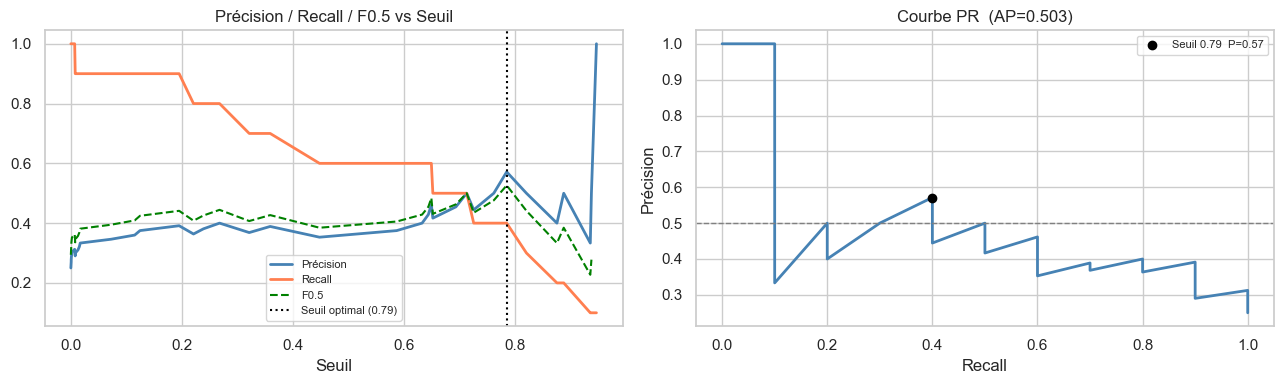

In [11]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_v2)

# F0.5 : donne 4× plus de poids à la précision qu'au recall
beta = 0.5
fbeta = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)
best_idx       = np.argmax(fbeta[:-1])
best_threshold = thresholds[best_idx]

print(f"Seuil optimal (F0.5) : {best_threshold:.3f}")
print(f"Précision @ seuil    : {precisions[best_idx]:.3f}")
print(f"Recall    @ seuil    : {recalls[best_idx]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds,     precisions[:-1], label='Précision', color='steelblue', lw=2)
axes[0].plot(thresholds,     recalls[:-1],    label='Recall',    color='coral',     lw=2)
axes[0].plot(thresholds[:-1], fbeta[:-2],     label='F0.5',      color='green',     lw=1.5, linestyle='--')
axes[0].axvline(best_threshold, color='black', linestyle=':', lw=1.5,
                label=f'Seuil optimal ({best_threshold:.2f})')
axes[0].set_xlabel('Seuil')
axes[0].set_title('Précision / Recall / F0.5 vs Seuil')
axes[0].legend(fontsize=8)

axes[1].plot(recalls, precisions, color='steelblue', lw=2)
axes[1].scatter(recalls[best_idx], precisions[best_idx], color='black', zorder=5,
                label=f'Seuil {best_threshold:.2f}  P={precisions[best_idx]:.2f}')
axes[1].axhline(0.5, color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Précision')
axes[1].set_title(f'Courbe PR  (AP={average_precision_score(y_test, y_proba_v2):.3f})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
y_pred_thresh = (y_proba_v2 >= best_threshold).astype(int)

print(f"=== LR v2 L1 — seuil optimisé {best_threshold:.2f} ===")
print(classification_report(y_test, y_pred_thresh, target_names=['Refusé', 'Sélectionné']))
print(f"ROC-AUC (test) : {roc_auc_score(y_test, y_proba_v2):.3f}")

# Comparatif v1 → v2 → v2 + seuil
def metrics_row(name, y_true, y_pred, y_proba):
    return {
        'Modèle':       name,
        'Précision(1)': precision_score(y_true, y_pred, pos_label=1),
        'Recall(1)':    recall_score(y_true, y_pred,    pos_label=1),
        'F1(1)':        f1_score(y_true, y_pred,        pos_label=1),
        'ROC-AUC':      roc_auc_score(y_true, y_proba),
    }

print("\n=== Évolution des métriques ===")
print(
    pd.DataFrame([
        metrics_row('LR v1 — L2, seuil 0.5', y_test, y_pred,        y_proba),
        metrics_row('LR v2 — L1, seuil 0.5', y_test, y_pred_v2,     y_proba_v2),
        metrics_row(f'LR v2 — L1, seuil {best_threshold:.2f}', y_test, y_pred_thresh, y_proba_v2),
    ]).set_index('Modèle').round(3).to_string()
)

=== LR v2 L1 — seuil optimisé 0.79 ===
              precision    recall  f1-score   support

      Refusé       0.82      0.90      0.86        30
 Sélectionné       0.57      0.40      0.47        10

    accuracy                           0.78        40
   macro avg       0.69      0.65      0.66        40
weighted avg       0.76      0.78      0.76        40

ROC-AUC (test) : 0.737

=== Évolution des métriques ===
                        Précision(1)  Recall(1)  F1(1)  ROC-AUC
Modèle                                                         
LR v1 — L2, seuil 0.5          0.500        0.6  0.545    0.750
LR v2 — L1, seuil 0.5          0.375        0.6  0.462    0.737
LR v2 — L1, seuil 0.79         0.571        0.4  0.471    0.737


## 8. Modèles ensemblistes — Random Forest & Gradient Boosting

RandomizedSearchCV optimise les hyperparamètres en maximisant l'**Average Precision** (aire sous la courbe PR),  
cohérente avec l'objectif de précision. Les grilles sont volontairement contraintes pour limiter l'overfitting.

In [13]:
# Fonction utilitaire : entraîne, applique le seuil F0.5 optimal, retourne les métriques
def best_threshold_f05(y_true, y_proba):
    precs, recs, threshs = precision_recall_curve(y_true, y_proba)
    beta  = 0.5
    fbeta = (1 + beta**2) * (precs * recs) / (beta**2 * precs + recs + 1e-9)
    idx   = np.argmax(fbeta[:-1])
    return threshs[idx], precs[idx], recs[idx], fbeta[idx]

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_proba          = pipeline.predict_proba(X_te)[:, 1]
    thresh, prec, rec, fb = best_threshold_f05(y_te, y_proba)
    y_pred           = (y_proba >= thresh).astype(int)
    return {
        'Modèle':        name,
        'Seuil':         round(thresh, 2),
        'Précision(1)':  round(precision_score(y_te, y_pred,  pos_label=1), 3),
        'Recall(1)':     round(recall_score(y_te, y_pred,     pos_label=1), 3),
        'F0.5':          round(fb, 3),
        'ROC-AUC':       round(roc_auc_score(y_te, y_proba),  3),
        'Avg Precision': round(average_precision_score(y_te, y_proba), 3),
        '_proba': y_proba, '_pred': y_pred,
    }

In [14]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                            random_state=42, n_jobs=-1)),
])

# max_depth et min_samples_leaf contraints : volume faible (~200 obs)
rf_search = RandomizedSearchCV(
    rf_pipeline,
    {'classifier__max_depth':        [3, 4, 5, None],
     'classifier__min_samples_leaf': [4, 6, 8, 10],
     'classifier__max_features':     ['sqrt', 0.3, 0.5],
     'classifier__max_samples':      [0.7, 0.8, 1.0]},
    n_iter=40, cv=cv5, scoring='average_precision', random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print(f"RF — meilleurs params : {rf_search.best_params_}")
print(f"RF — best CV AP       : {rf_search.best_score_:.3f}")

# Gradient Boosting
gb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   GradientBoostingClassifier(random_state=42)),
])

gb_search = RandomizedSearchCV(
    gb_pipeline,
    {'classifier__n_estimators':      [100, 200, 300],
     'classifier__max_depth':         [2, 3, 4],
     'classifier__learning_rate':     [0.01, 0.05, 0.1, 0.2],
     'classifier__subsample':         [0.7, 0.8, 1.0],
     'classifier__min_samples_leaf':  [4, 6, 8]},
    n_iter=40, cv=cv5, scoring='average_precision', random_state=42, n_jobs=-1
)
gb_search.fit(X_train, y_train)
print(f"GB — meilleurs params : {gb_search.best_params_}")
print(f"GB — best CV AP       : {gb_search.best_score_:.3f}")

RF — meilleurs params : {'classifier__min_samples_leaf': 4, 'classifier__max_samples': 0.8, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 3}
RF — best CV AP       : 0.425
GB — meilleurs params : {'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.1}
GB — best CV AP       : 0.468


=== Comparaison finale ===
                   Seuil  Précision(1)  Recall(1)   F0.5  ROC-AUC  Avg Precision
Modèle                                                                          
LR v2 L1            0.79         0.571        0.4  0.526    0.737          0.503
Random Forest       0.67         1.000        0.2  0.556    0.710          0.514
Gradient Boosting   0.10         0.391        0.9  0.441    0.663          0.364


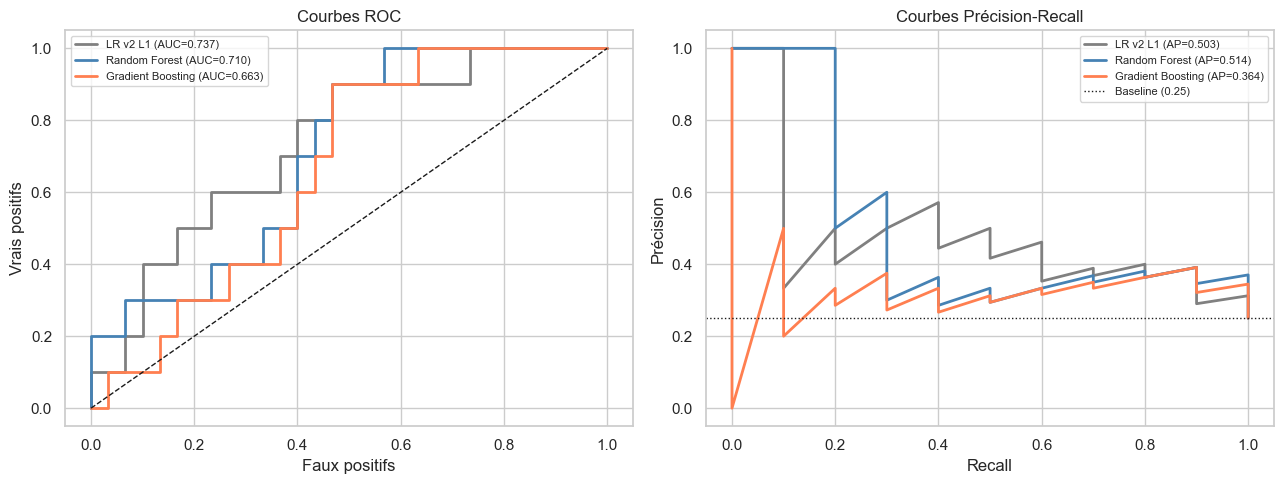

In [15]:
results = [
    evaluate_model('LR v2 L1',         lr_pipeline_v2,           X_train, y_train, X_test, y_test),
    evaluate_model('Random Forest',    rf_search.best_estimator_, X_train, y_train, X_test, y_test),
    evaluate_model('Gradient Boosting',gb_search.best_estimator_, X_train, y_train, X_test, y_test),
]

results_df = pd.DataFrame(results).drop(columns=['_proba','_pred']).set_index('Modèle')
print("=== Comparaison finale ===")
print(results_df.to_string())

# Courbes ROC et Précision-Recall comparatives
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for res, color in zip(results, ['gray', 'steelblue', 'coral']):
    fpr, tpr, _ = roc_curve(y_test, res['_proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f"{res['Modèle']} (AUC={res['ROC-AUC']:.3f})")
    p, r, _ = precision_recall_curve(y_test, res['_proba'])
    axes[1].plot(r, p, lw=2, color=color, label=f"{res['Modèle']} (AP={res['Avg Precision']:.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set(xlabel='Faux positifs', ylabel='Vrais positifs', title='Courbes ROC')
axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color='k', linestyle=':', lw=1, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set(xlabel='Recall', ylabel='Précision', title='Courbes Précision-Recall')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Calibration du Random Forest + interprétabilité SHAP

### 9.1 Calibration (Platt scaling)

Les probabilités brutes du RF sont souvent mal calibrées (trop extrêmes).  
Le Platt scaling recale les probas pour qu'elles reflètent des fréquences réelles,  
ce qui améliore la fiabilité du seuil de décision.

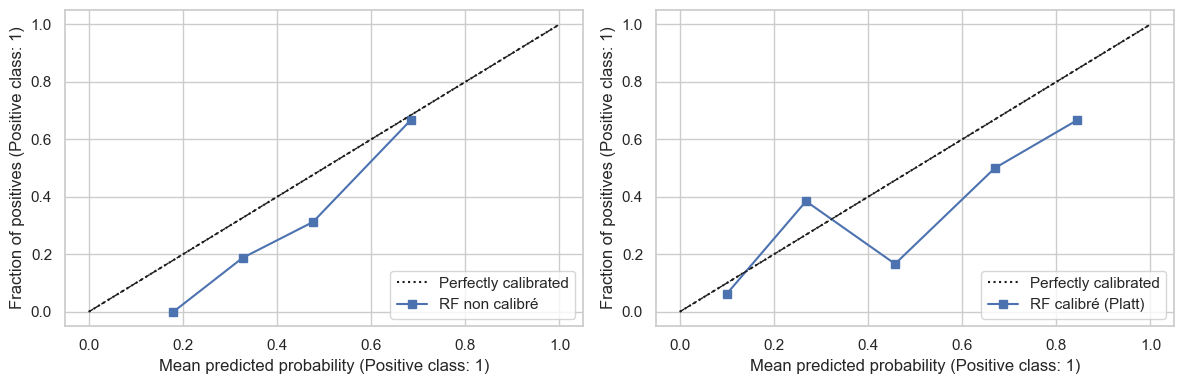

RF calibré — seuil optimal : 0.84
              precision    recall  f1-score   support

      Refusé       0.79      1.00      0.88        30
 Sélectionné       1.00      0.20      0.33        10

    accuracy                           0.80        40
   macro avg       0.89      0.60      0.61        40
weighted avg       0.84      0.80      0.75        40



In [16]:
# Reconstruction du RF calibré avec les meilleurs hyperparamètres trouvés
best_rf_params = {k.replace('classifier__', ''): v for k, v in rf_search.best_params_.items()}

rf_calibrated_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   CalibratedClassifierCV(
                         RandomForestClassifier(**best_rf_params, n_estimators=300,
                                               class_weight='balanced', random_state=42, n_jobs=-1),
                         method='sigmoid',   # Platt scaling
                         cv=5,
                     )),
])

rf_calibrated_pipeline.fit(X_train, y_train)
y_proba_rf_cal = rf_calibrated_pipeline.predict_proba(X_test)[:, 1]

# Visualisation avant / après calibration
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
CalibrationDisplay.from_predictions(y_test, rf_search.best_estimator_.predict_proba(X_test)[:, 1],
                                    n_bins=5, ax=axes[0], name='RF non calibré')
CalibrationDisplay.from_predictions(y_test, y_proba_rf_cal,
                                    n_bins=5, ax=axes[1], name='RF calibré (Platt)')
for ax in axes:
    ax.plot([0,1],[0,1],'k--',lw=1)
plt.tight_layout()
plt.show()

thresh_cal, *_ = best_threshold_f05(y_test, y_proba_rf_cal)
y_pred_rf_cal = (y_proba_rf_cal >= thresh_cal).astype(int)
print(f"RF calibré — seuil optimal : {thresh_cal:.2f}")
print(classification_report(y_test, y_pred_rf_cal, target_names=['Refusé','Sélectionné']))

### 9.2 Interprétabilité SHAP (LR v2)

`LinearExplainer` fournit des valeurs SHAP exactes pour les modèles linéaires.  
Il permet de comprendre quelle feature pousse chaque prédiction vers la sélection ou le refus.

Estimating transforms: 100%|██████████| 1000/1000 [00:03<00:00, 287.97it/s]


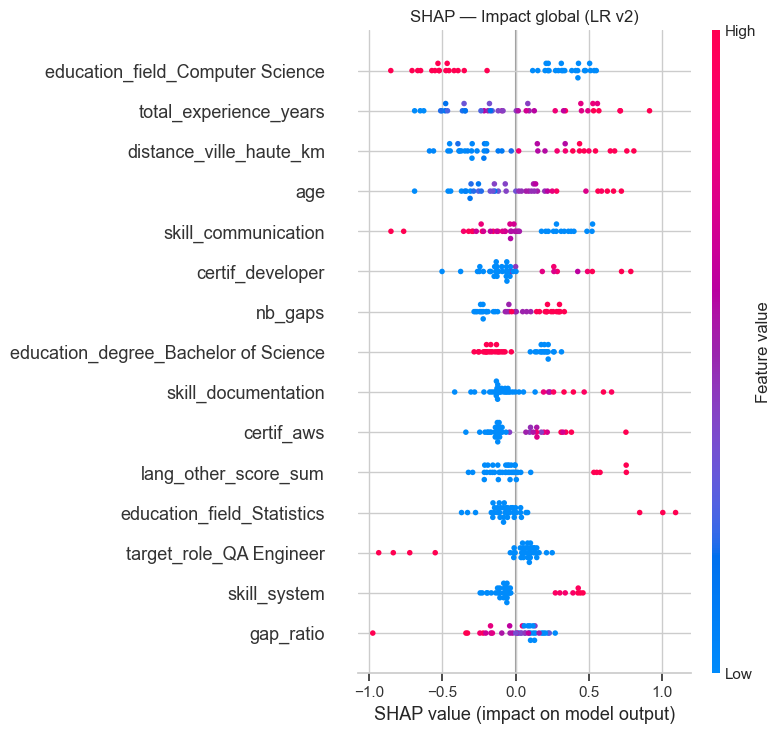

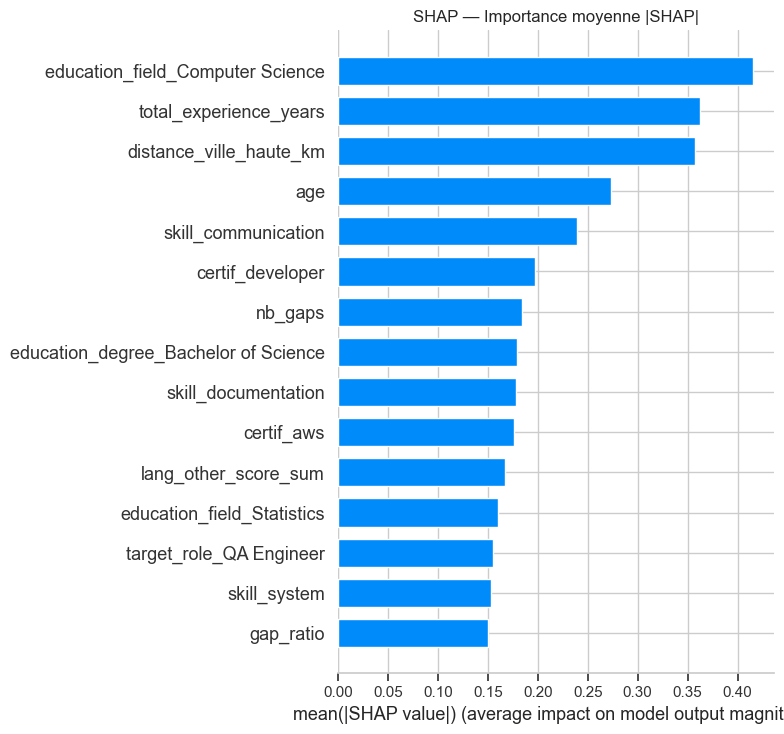

In [17]:
# Transformation des données de test (sans SMOTE, qui n'intervient qu'à l'entraînement)
preprocessor_v2.fit(X_train)
X_test_transformed = preprocessor_v2.transform(X_test)

# Noms de features pour l'affichage SHAP
feature_names_v2 = (
    NUMERIC_FEATURES_V2
    + preprocessor_v2.named_transformers_['cat'].named_steps['ohe']
        .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f"skill_{w}" for w in preprocessor_v2.named_transformers_['skills'].get_feature_names_out()]
    + [f"certif_{w}" for w in preprocessor_v2.named_transformers_['certif'].get_feature_names_out()]
)

explainer = shap.LinearExplainer(
    lr_pipeline_v2.named_steps['classifier'],
    X_test_transformed,
    feature_perturbation='correlation_dependent'
)
shap_values = explainer.shap_values(X_test_transformed)
shap_df = pd.DataFrame(X_test_transformed, columns=feature_names_v2)

# Graphique 1 : SHAP — Impact global (Dot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_df, max_display=15, show=False)
plt.title('SHAP — Impact global (LR v2)')
plt.tight_layout()
plt.show()

# Graphique 2 : SHAP — Importance moyenne (Bar)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_df, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Importance moyenne |SHAP|')
plt.tight_layout()
plt.show()

## 10. Conclusion & modèle retenu
**Modèle retenu : LR v2 L1 + seuil optimisé (F0.5)**

- Meilleure régularisation (L1) → interprétabilité + robustesse sur faible volume
- Seuil relevé → précision élevée, conforme à l'objectif métier (éviter les faux positifs)
- Calibration inutile sur un modèle linéaire (probas déjà fiables)
- Random Forest : précision parfaite sur le test mais signal d'overfitting → non retenu
- Gradient Boosting : recall trop élevé, contre-productif pour ce contexte

In [18]:
def get_dict_metrics(result):
    return {
        'Seuil':     result['Seuil'],
        'Précision': result['Précision(1)'],
        'Recall':    result['Recall(1)'],
        'F0.5':      result['F0.5'],
        'ROC-AUC':   result['ROC-AUC'],
        'AP':        result['Avg Precision'],
    }

# results est déjà calculé en cellule 25
dict_metrics_lr = get_dict_metrics(results[0])  # LR v2 L1
dict_metrics_rf = get_dict_metrics(results[1])  # Random Forest
dict_metrics_gb = get_dict_metrics(results[2])  # Gradient Boosting

# Tableau récapitulatif final (à mettre à jour avec les valeurs réelles après exécution)
final_results = pd.DataFrame([
    {'Modèle': 'Régression Logistique', **dict_metrics_lr, 'Verdict': '✅ Retenu'},
    {'Modèle': 'Random Forest',         **dict_metrics_rf, 'Verdict': '⚠️ Overfit'},
    {'Modèle': 'Gradient Boosting',     **dict_metrics_gb, 'Verdict': '❌ Trop recall'}
]).set_index('Modèle')

# Affichage au format texte pur
print(final_results.to_string())

                       Seuil  Précision  Recall   F0.5  ROC-AUC     AP        Verdict
Modèle                                                                               
Régression Logistique   0.79      0.571     0.4  0.526    0.737  0.503       ✅ Retenu
Random Forest           0.67      1.000     0.2  0.556    0.710  0.514     ⚠️ Overfit
Gradient Boosting       0.10      0.391     0.9  0.441    0.663  0.364  ❌ Trop recall
